# Notebook 01: ReliefWeb API Collection Pipeline

## Project 8: Digital Trace Data Collection for Conflict Research

### Overview

In this notebook, I build a complete data collection pipeline using the ReliefWeb API. ReliefWeb is the United Nations Office for the Coordination of Humanitarian Affairs (OCHA) information platform. It aggregates situation reports, press releases, needs assessments, and analyses published by UN agencies, NGOs, and governments worldwide.

The API (api.reliefweb.int) provides structured access to this content: full text, publication dates, source organizations, country tags, report format types, and thematic tags. The API is free, requires no authentication, has generous rate limits, and returns clean JSON responses.

**Research context:** I collect all humanitarian reports tagged to Ethiopia between November 2020 and November 2022, the period of the Tigray conflict. This corpus will later be compared to UCDP violence data from Project 1 and GDELT media coverage from Notebook 02 to identify reporting gaps and surges, particularly during communications blackout periods.

**What I learn here:**
- How to construct HTTP API requests with JSON payloads
- How to handle pagination to collect all results from an API
- How to implement error handling and retry logic for robust collection
- How to parse nested JSON responses into a flat pandas DataFrame
- How to save raw and processed data following data science best practices

## 1. Setup and Configuration

I start by importing the libraries I need and setting the working directory. The `requests` library handles HTTP calls to the API. `time` provides the `sleep()` function for rate limiting between requests. `json` parses the API responses. `pandas` structures the collected data into a DataFrame for analysis.

I also define all collection parameters upfront: the API endpoint, date range, country filter, and fields to retrieve. Keeping these in one place makes the pipeline easy to modify and reproduce.

In [1]:
import os
import requests
import time
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Set working directory
os.chdir('/Users/cansezgin/Library/Mobile Documents/com~apple~CloudDocs/Claude_Projects/Computational Social Sciences/conflict-data-collection')

# Verify
print('Working directory:', os.getcwd())

Working directory: /Users/cansezgin/Library/Mobile Documents/com~apple~CloudDocs/Claude_Projects/Computational Social Sciences/conflict-data-collection


## 2. API Configuration

The ReliefWeb API accepts POST requests with a JSON body that specifies what data I want. The key parts of the configuration are:

- **Endpoint:** `https://api.reliefweb.int/v1/reports` returns humanitarian reports.
- **App name:** ReliefWeb asks that API users identify themselves with an `appname` parameter. This is not authentication. It helps ReliefWeb track API usage patterns and contact users if there is an issue.
- **Filters:** I filter by country (Ethiopia) and date range (November 1, 2020 to November 30, 2022) to match the Tigray conflict study period from Project 1.
- **Fields:** I request specific fields rather than the full record. This keeps responses smaller and faster. The fields I request include the report title, publication date, source organization, full body text, URL, format type, and thematic tags.
- **Pagination:** The API returns a maximum of 1,000 results per request. I set the page size (`limit`) to 1,000 and use the `offset` parameter to paginate through all results.

In [2]:
# API configuration
# V2 is the current version; V1 is deprecated
API_URL = 'https://api.reliefweb.int/v2/reports'

# Appname goes in the URL, not the JSON body
# ReliefWeb uses this to track API usage
APPNAME = 'CanSTZ46S7Mvp-JUR7FIF'

# Collection parameters
COUNTRY = 'Ethiopia'
DATE_START = '2020-11-01T00:00:00+00:00'
DATE_END = '2022-11-30T23:59:59+00:00'
PAGE_SIZE = 1000  # Maximum allowed by the API

# Fields to retrieve from each report
FIELDS = [
    'id',
    'title',
    'date.original',
    'source',
    'body',
    'url',
    'format',
    'theme',
    'status'
]

print(f'Endpoint: {API_URL}')
print(f'Target: {COUNTRY} reports from {DATE_START} to {DATE_END}')
print(f'Fields requested: {len(FIELDS)}')
print(f'Page size: {PAGE_SIZE}')

Endpoint: https://api.reliefweb.int/v2/reports
Target: Ethiopia reports from 2020-11-01T00:00:00+00:00 to 2022-11-30T23:59:59+00:00
Fields requested: 9
Page size: 1000


## 3. Building the API Request

I now construct the JSON payload that the ReliefWeb API expects. The payload has three main sections:

- **filter:** A nested structure that combines multiple conditions with an `operator`. I use the `AND` operator to require that results match both the country filter and the date range filter. The country filter uses the `value` operator to match "Ethiopia" exactly. The date range filter uses the `range` operator to specify a `from` and `to` date.
- **fields:** A list of field names to include in the response. Requesting only the fields I need reduces response size and speeds up collection.
- **limit and offset:** Control pagination. `limit` sets the number of results per request (maximum 1,000). `offset` tells the API how many results to skip, which I increment by `limit` after each request.

I wrap the request logic in a function called `build_request_payload()` so I call it repeatedly with different offset values during pagination.

In [3]:
def build_request_payload(offset=0):
    """
    Build the JSON payload for a ReliefWeb API request.
    
    Parameters:
        offset (int): Number of results to skip (for pagination)
    
    Returns:
        dict: JSON-serializable payload for the API POST request
    """
    payload = {
        'filter': {
            'operator': 'AND',
            'conditions': [
                {
                    'field': 'country.name',
                    'value': COUNTRY
                },
                {
                    'field': 'date.original',
                    'value': {
                        'from': DATE_START,
                        'to': DATE_END
                    }
                }
            ]
        },
        'fields': {
            'include': FIELDS
        },
        'limit': PAGE_SIZE,
        'offset': offset,
        'sort': ['date.original:asc']
    }
    return payload

# Preview the payload structure
sample_payload = build_request_payload(offset=0)
print(json.dumps(sample_payload, indent=2))

{
  "filter": {
    "operator": "AND",
    "conditions": [
      {
        "field": "country.name",
        "value": "Ethiopia"
      },
      {
        "field": "date.original",
        "value": {
          "from": "2020-11-01T00:00:00+00:00",
          "to": "2022-11-30T23:59:59+00:00"
        }
      }
    ]
  },
  "fields": {
    "include": [
      "id",
      "title",
      "date.original",
      "source",
      "body",
      "url",
      "format",
      "theme",
      "status"
    ]
  },
  "limit": 1000,
  "offset": 0,
  "sort": [
    "date.original:asc"
  ]
}


## 4. Making a Single API Request

Before building the full pagination loop, I write a function that makes a single API call and handles potential errors. Robust error handling is essential for data collection pipelines because network issues, rate limits, and server errors happen regularly.

The function implements three safeguards:

1. **Retry logic:** If a request fails with a 429 (rate limit) or 5xx (server error) status code, the function waits and retries up to 3 times. The wait time increases with each retry (exponential backoff), which gives the server time to recover.
2. **Timeout:** Each request has a 30-second timeout. If the server does not respond within 30 seconds, the request fails rather than hanging indefinitely.
3. **Response validation:** The function checks the HTTP status code before parsing the response. A 200 status means success. Anything else triggers a retry or raises an error.

In [4]:
def make_api_request(payload, max_retries=3):
    """
    Make a single POST request to the ReliefWeb API with retry logic.
    
    Parameters:
        payload (dict): JSON payload for the request
        max_retries (int): Maximum number of retry attempts
    
    Returns:
        dict: Parsed JSON response from the API
    
    Raises:
        Exception: If all retry attempts fail
    """
    # Appname goes in the URL as a query parameter
    url_with_appname = f'{API_URL}?appname={APPNAME}'
    
    for attempt in range(max_retries):
        try:
            response = requests.post(
                url_with_appname,
                json=payload,
                timeout=30
            )
            
            # Success
            if response.status_code == 200:
                return response.json()
            
            # Rate limit or server error: wait and retry
            if response.status_code in [429, 500, 502, 503, 504]:
                wait_time = 2 ** (attempt + 1)
                print(f'  Status {response.status_code}, retrying in {wait_time}s (attempt {attempt + 1}/{max_retries})')
                time.sleep(wait_time)
                continue
            
            # Other error: print the response body for debugging, then raise
            print(f'  Status {response.status_code}')
            print(f'  Response: {response.text[:500]}')
            response.raise_for_status()
            
        except requests.exceptions.Timeout:
            wait_time = 2 ** (attempt + 1)
            print(f'  Timeout, retrying in {wait_time}s (attempt {attempt + 1}/{max_retries})')
            time.sleep(wait_time)
            
        except requests.exceptions.ConnectionError:
            wait_time = 2 ** (attempt + 1)
            print(f'  Connection error, retrying in {wait_time}s (attempt {attempt + 1}/{max_retries})')
            time.sleep(wait_time)
    
    raise Exception(f'API request failed after {max_retries} attempts')

# Test with a small request (limit=2 to verify the API works)
test_payload = build_request_payload(offset=0)
test_payload['limit'] = 2  # Only fetch 2 reports for testing

test_response = make_api_request(test_payload)
print(f"Total reports available: {test_response['totalCount']}")
print(f"Reports returned in test: {len(test_response['data'])}")
print(f"\nFirst report title: {test_response['data'][0]['fields']['title']}")

Total reports available: 6295
Reports returned in test: 2

First report title: Government of Uganda Office of the Prime Minister: Uganda Refugees & Asylum Seekers as of 02/Nov/2020


## 5. Understanding the Response Structure

Before building the full collection loop, I examine one report's JSON structure in detail. This tells me exactly how to parse each field. API responses often have nested structures where useful data is buried several levels deep. Examining one record closely prevents parsing errors later.

The ReliefWeb API wraps each report's data inside a `fields` key. Some fields like `source`, `format`, and `theme` are lists of objects (a report has multiple sources or themes), so I need to extract and flatten them.

In [5]:
# Look at the structure of one report
sample_report = test_response['data'][0]
print('Top-level keys:', list(sample_report.keys()))
print()
print('Fields available:', list(sample_report['fields'].keys()))
print()

# Examine nested fields
fields = sample_report['fields']

print('--- Title ---')
print(fields.get('title', 'N/A'))
print()

print('--- Date ---')
print(fields.get('date', {}).get('original', 'N/A'))
print()

print('--- Source (first entry) ---')
sources = fields.get('source', [])
if sources:
    print(sources[0])
print()

print('--- Format ---')
formats = fields.get('format', [])
if formats:
    print(formats[0])
print()

print('--- Theme tags ---')
themes = fields.get('theme', [])
for t in themes[:5]:
    print(f"  {t.get('name', 'N/A')}")
print()

print('--- Body text (first 500 chars) ---')
body = fields.get('body', 'N/A')
print(body[:500] if body else 'No body text')

Top-level keys: ['id', 'score', 'fields', 'href']

Fields available: ['id', 'title', 'status', 'source', 'theme', 'format', 'url', 'date']

--- Title ---
Government of Uganda Office of the Prime Minister: Uganda Refugees & Asylum Seekers as of 02/Nov/2020

--- Date ---
2020-11-02T00:00:00+00:00

--- Source (first entry) ---
{'href': 'https://api.reliefweb.int/v2/sources/756', 'id': 756, 'name': 'Government of Uganda', 'shortname': 'Govt. Uganda', 'longname': 'Government of Uganda', 'homepage': 'http://www.statehouse.go.ug/', 'type': {'id': 271, 'name': 'Government'}}

--- Format ---
{'id': 9, 'name': 'Other'}

--- Theme tags ---
  Protection and Human Rights

--- Body text (first 500 chars) ---
N/A


## 6. Full Collection with Pagination

Now I build the main collection loop. The strategy is straightforward:

1. Make the first request with `offset=0` to get the first batch and the `totalCount`.
2. Store the results.
3. Increment the offset by the page size and request the next batch.
4. Repeat until the offset exceeds the total count.
5. Add a 1-second delay between requests to respect the server.

I collect raw JSON responses first and parse them into a DataFrame afterward. Separating collection from parsing is a best practice: if parsing fails, I still have the raw data and do not need to re-collect.

In [6]:
def collect_all_reports():
    """
    Collect all ReliefWeb reports matching the configured filters.
    Uses pagination to retrieve all results.
    
    Returns:
        list: Raw report records (each is a dict with 'id', 'fields' keys)
        int: Total count reported by the API
    """
    all_reports = []
    offset = 0
    total_count = None
    
    print('Starting collection...')
    print(f'Country: {COUNTRY}')
    print(f'Date range: {DATE_START} to {DATE_END}')
    print()
    
    while True:
        payload = build_request_payload(offset=offset)
        response_data = make_api_request(payload)
        
        # On first request, get the total count
        if total_count is None:
            total_count = response_data['totalCount']
            print(f'Total reports to collect: {total_count}')
            print()
        
        # Extract reports from this batch
        batch = response_data.get('data', [])
        if not batch:
            break
        
        all_reports.extend(batch)
        print(f'  Collected {len(all_reports)} / {total_count} reports (offset={offset})')
        
        # Check if I have collected everything
        offset += PAGE_SIZE
        if offset >= total_count:
            break
        
        # Rate limiting: wait between requests
        time.sleep(1)
    
    print()
    print(f'Collection complete: {len(all_reports)} reports collected')
    return all_reports, total_count

# Run the collection
raw_reports, total_count = collect_all_reports()

Starting collection...
Country: Ethiopia
Date range: 2020-11-01T00:00:00+00:00 to 2022-11-30T23:59:59+00:00

Total reports to collect: 6295

  Collected 1000 / 6295 reports (offset=0)
  Collected 2000 / 6295 reports (offset=1000)
  Collected 3000 / 6295 reports (offset=2000)
  Collected 4000 / 6295 reports (offset=3000)
  Collected 5000 / 6295 reports (offset=4000)
  Collected 6000 / 6295 reports (offset=5000)
  Collected 6295 / 6295 reports (offset=6000)

Collection complete: 6295 reports collected


## 7. Save Raw Data

I save the raw API responses immediately before any parsing or cleaning. This follows the principle: never lose your raw data. If I make a parsing mistake later, I reload from this file instead of re-collecting from the API.

I save as JSON because the API returns nested structures (lists of sources, lists of themes) that would be lost in a flat CSV format. The JSON file preserves the complete original structure.

In [7]:
# Save raw responses to JSON
raw_output = {
    'collection_metadata': {
        'source': 'ReliefWeb API',
        'endpoint': API_URL,
        'country': COUNTRY,
        'date_start': DATE_START,
        'date_end': DATE_END,
        'total_count': total_count,
        'collected_count': len(raw_reports),
        'collection_date': datetime.now().isoformat()
    },
    'reports': raw_reports
}

with open('data/raw/reliefweb_raw.json', 'w', encoding='utf-8') as f:
    json.dump(raw_output, f, ensure_ascii=False, indent=2)

file_size = os.path.getsize('data/raw/reliefweb_raw.json') / (1024 * 1024)
print(f'Raw data saved to data/raw/reliefweb_raw.json')
print(f'File size: {file_size:.1f} MB')

Raw data saved to data/raw/reliefweb_raw.json
File size: 27.7 MB


## 8. Parse Raw Data into a DataFrame

Now I parse the nested JSON into a flat pandas DataFrame. This requires extracting values from nested dictionaries and handling fields that contain lists of objects.

Key parsing decisions:

- **Source organizations:** A report often has multiple sources (e.g., both OCHA and WFP). I extract the name from the first source as the `primary_source` and store all source names as a semicolon-separated string in `all_sources`.
- **Format type:** Report format (situation report, press release, assessment, etc.) comes as a list. I take the first entry's name.
- **Theme tags:** Themes are a list of tagged topics. I join all theme names into a single string.
- **Body text:** The full HTML body text. I keep it as-is for now. Cleaning HTML tags is a processing step I do later if needed.
- **Date:** I parse the original date string into a proper datetime object for time series analysis.

In [8]:
def parse_report(report):
    """
    Parse a single raw API report record into a flat dictionary.
    
    Parameters:
        report (dict): Raw report record from the API
    
    Returns:
        dict: Flat dictionary with parsed fields
    """
    fields = report.get('fields', {})
    
    # Extract sources
    sources = fields.get('source', [])
    source_names = [s.get('name', 'Unknown') for s in sources]
    primary_source = source_names[0] if source_names else 'Unknown'
    
    # Extract format
    formats = fields.get('format', [])
    format_name = formats[0].get('name', 'Unknown') if formats else 'Unknown'
    
    # Extract themes
    themes = fields.get('theme', [])
    theme_names = [t.get('name', '') for t in themes]
    
    # Extract date
    date_info = fields.get('date', {})
    date_str = date_info.get('original', None) if isinstance(date_info, dict) else None
    
    # Extract body text
    body = fields.get('body', '')
    
    return {
        'id': report.get('id', ''),
        'title': fields.get('title', ''),
        'date': date_str,
        'primary_source': primary_source,
        'all_sources': '; '.join(source_names),
        'format_type': format_name,
        'themes': '; '.join(theme_names),
        'body_text': body,
        'url': fields.get('url', ''),
        'body_length': len(body) if body else 0
    }

# Parse all reports
parsed_records = [parse_report(r) for r in raw_reports]
df = pd.DataFrame(parsed_records)

# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'], utc=True, errors='coerce')

# Create year-month column for time series
df['year_month'] = df['date'].dt.to_period('M')

print(f'DataFrame shape: {df.shape}')
print(f'\nColumn types:')
print(df.dtypes)
print(f'\nDate range: {df["date"].min()} to {df["date"].max()}')

DataFrame shape: (6295, 11)

Column types:
id                             object
title                          object
date              datetime64[ns, UTC]
primary_source                 object
all_sources                    object
format_type                    object
themes                         object
body_text                      object
url                            object
body_length                     int64
year_month                  period[M]
dtype: object

Date range: 2020-11-02 00:00:00+00:00 to 2022-11-30 00:00:00+00:00


/var/folders/ls/jfgzf4j13hx__mtdgv2_0xbw0000gn/T/ipykernel_56822/1957106635.py:54: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['year_month'] = df['date'].dt.to_period('M')


## 9. First Look at the Data

I examine the DataFrame to verify the parsing worked correctly and to get a first sense of what I collected.

In [10]:
# Preview the first few records
print('=== First 5 Reports ===')
print(df[['title', 'date', 'primary_source', 'format_type']].head())
print()

# Check for missing values
print('=== Missing Values ===')
print(df.isnull().sum())
print()

# Basic stats
print('=== Body Text Length Stats ===')
print(df['body_length'].describe())

=== First 5 Reports ===
                                               title  \
0  Government of Uganda Office of the Prime Minis...   
1                      Saving lives with ventilators   
2  Ethiopia: ICRC restores access to clean water ...   
3  Desert Locust Bulletin 505 (2 November 2020) [...   
4  Somalia: Cross Border Movements - Week 44 (25 ...   

                       date  \
0 2020-11-02 00:00:00+00:00   
1 2020-11-02 00:00:00+00:00   
2 2020-11-02 00:00:00+00:00   
3 2020-11-02 00:00:00+00:00   
4 2020-11-02 00:00:00+00:00   

                                      primary_source             format_type  
0                               Government of Uganda                   Other  
1            US Agency for International Development  News and Press Release  
2           International Committee of the Red Cross  News and Press Release  
3  Food and Agriculture Organization of the Unite...        Situation Report  
4           International Organization for Migration     

## 10. Exploratory Analysis: Report Volume Over Time

The first analytical question: how does humanitarian reporting volume change over the study period? I expect to see patterns that reflect the conflict timeline: high reporting at the start of the conflict (November 2020), possible dips during the communications blackout, spikes when famine reports emerged (mid-2021), and increased coverage around the ceasefire negotiations (late 2022).

This time series will later be compared to UCDP event counts from Project 1 to identify where reporting tracks violence and where gaps appear.

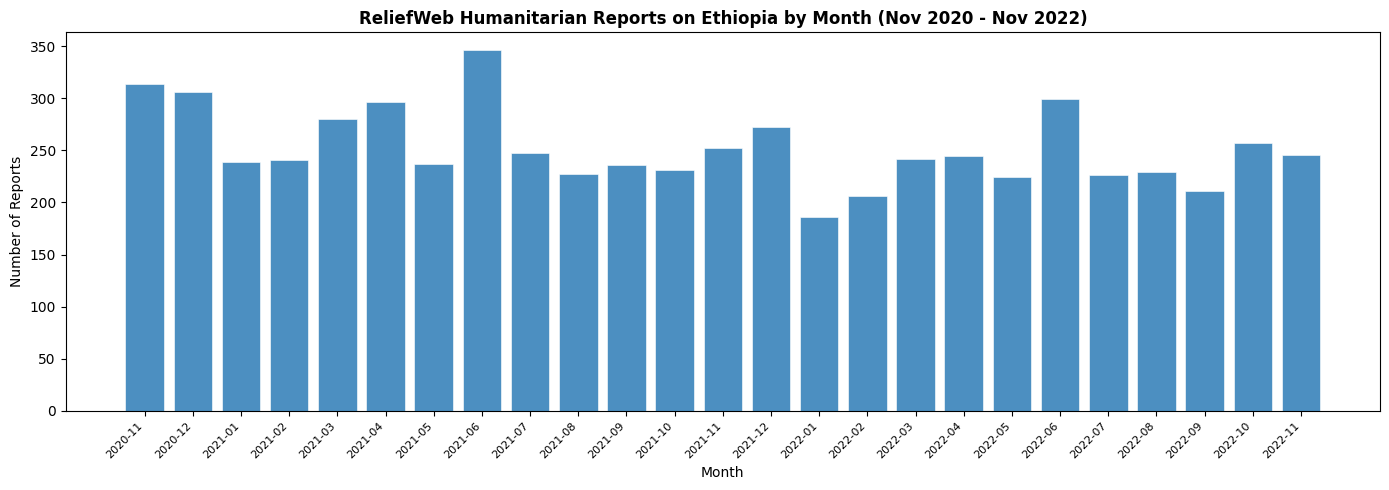


Total reports: 6295
Monthly average: 251.8
Highest month: 2021-06 (346 reports)
Lowest month: 2022-01 (186 reports)


In [11]:
# Monthly report counts
monthly_counts = df.groupby('year_month').size().reset_index(name='report_count')
monthly_counts['year_month_str'] = monthly_counts['year_month'].astype(str)

# Plot
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(range(len(monthly_counts)), monthly_counts['report_count'], 
       color='#2c7bb6', alpha=0.85, edgecolor='white', linewidth=0.5)

# X-axis labels
ax.set_xticks(range(len(monthly_counts)))
ax.set_xticklabels(monthly_counts['year_month_str'], rotation=45, ha='right', fontsize=8)

# Annotate key events
ax.set_title('ReliefWeb Humanitarian Reports on Ethiopia by Month (Nov 2020 - Nov 2022)', 
             fontsize=12, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Reports')

plt.tight_layout()
plt.savefig('figures/reliefweb_monthly_volume.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nTotal reports: {monthly_counts["report_count"].sum()}')
print(f'Monthly average: {monthly_counts["report_count"].mean():.1f}')
print(f'Highest month: {monthly_counts.loc[monthly_counts["report_count"].idxmax(), "year_month_str"]} '
      f'({monthly_counts["report_count"].max()} reports)')
print(f'Lowest month: {monthly_counts.loc[monthly_counts["report_count"].idxmin(), "year_month_str"]} '
      f'({monthly_counts["report_count"].min()} reports)')

## 11. Source Organizations

I analyze which organizations published the most reports about Ethiopia during this period. This reveals the information ecosystem behind humanitarian data. UN agencies like OCHA, WFP, and UNHCR typically dominate, but NGOs like Médecins Sans Frontières or the Norwegian Refugee Council also contribute. Understanding who reports (and who stops reporting during blackout periods) matters for assessing data completeness.

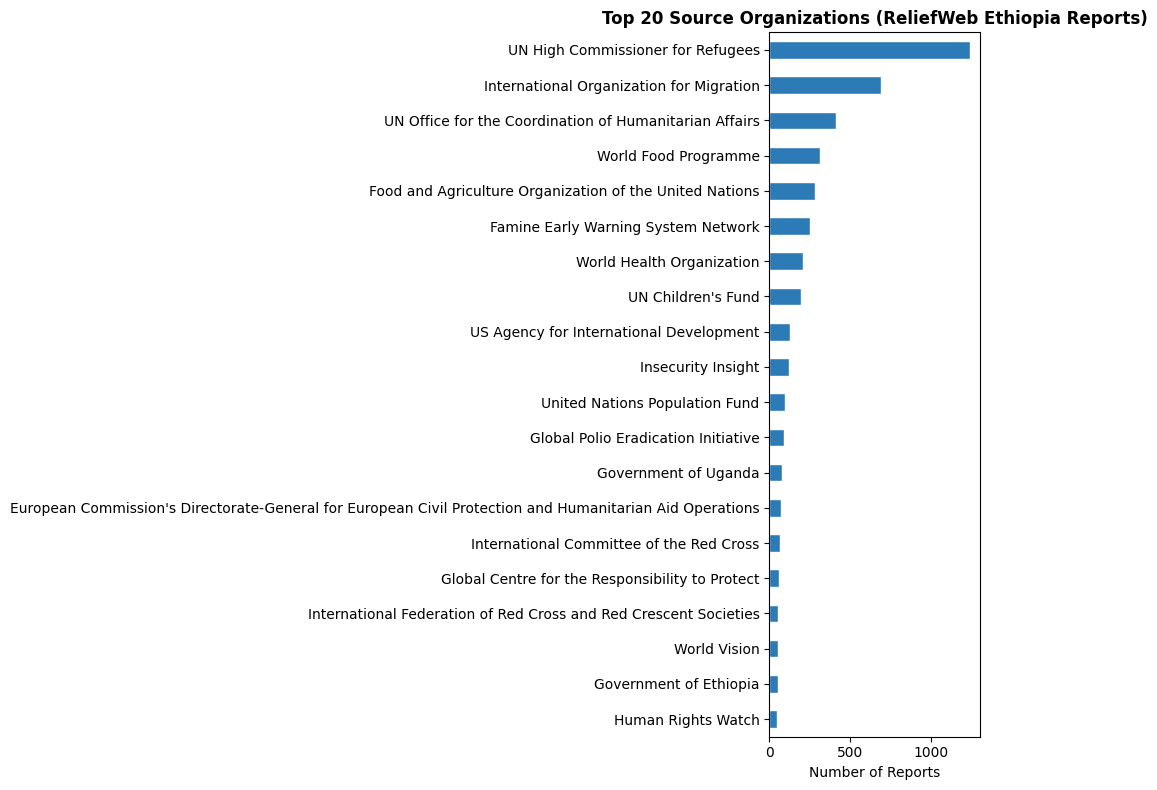


Total unique source organizations: 292

Top 10 sources:
  UN High Commissioner for Refugees: 1243 reports (19.7%)
  International Organization for Migration: 690 reports (11.0%)
  UN Office for the Coordination of Humanitarian Affairs: 415 reports (6.6%)
  World Food Programme: 313 reports (5.0%)
  Food and Agriculture Organization of the United Nations: 284 reports (4.5%)
  Famine Early Warning System Network: 254 reports (4.0%)
  World Health Organization: 207 reports (3.3%)
  UN Children's Fund: 196 reports (3.1%)
  US Agency for International Development: 131 reports (2.1%)
  Insecurity Insight: 124 reports (2.0%)


In [12]:
# Top source organizations
source_counts = df['primary_source'].value_counts()

# Plot top 20 sources
top_n = 20
fig, ax = plt.subplots(figsize=(10, 8))
source_counts.head(top_n).plot(kind='barh', ax=ax, color='#2c7bb6', edgecolor='white')
ax.set_title(f'Top {top_n} Source Organizations (ReliefWeb Ethiopia Reports)', fontsize=12, fontweight='bold')
ax.set_xlabel('Number of Reports')
ax.set_ylabel('')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('figures/reliefweb_top_sources.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nTotal unique source organizations: {df["primary_source"].nunique()}')
print(f'\nTop 10 sources:')
for org, count in source_counts.head(10).items():
    print(f'  {org}: {count} reports ({count/len(df)*100:.1f}%)')

## 12. Report Format Types

ReliefWeb categorizes reports by format: situation reports, press releases, needs assessments, analyses, maps, and others. The distribution of format types tells me what kind of information dominates the humanitarian reporting ecosystem. Situation reports typically contain the most detailed operational information, while press releases tend to be shorter and more focused on advocacy.

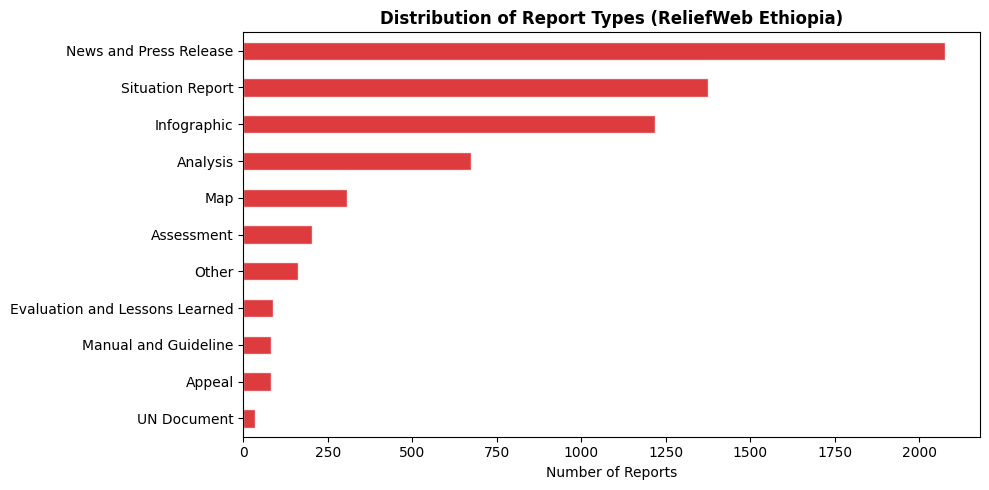


Report format distribution:
  News and Press Release: 2076 (33.0%)
  Situation Report: 1376 (21.9%)
  Infographic: 1217 (19.3%)
  Analysis: 672 (10.7%)
  Map: 305 (4.8%)
  Assessment: 204 (3.2%)
  Other: 160 (2.5%)
  Evaluation and Lessons Learned: 88 (1.4%)
  Manual and Guideline: 81 (1.3%)
  Appeal: 81 (1.3%)
  UN Document: 35 (0.6%)


In [13]:
# Report format distribution
format_counts = df['format_type'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
format_counts.plot(kind='barh', ax=ax, color='#d7191c', edgecolor='white', alpha=0.85)
ax.set_title('Distribution of Report Types (ReliefWeb Ethiopia)', fontsize=12, fontweight='bold')
ax.set_xlabel('Number of Reports')
ax.set_ylabel('')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('figures/reliefweb_format_types.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nReport format distribution:')
for fmt, count in format_counts.items():
    print(f'  {fmt}: {count} ({count/len(df)*100:.1f}%)')

## 13. Thematic Tags Analysis

Each report on ReliefWeb is tagged with thematic labels such as "Food and Nutrition," "Protection and Human Rights," "Health," and "Peacekeeping and Peacebuilding." Analyzing theme frequency shows which humanitarian concerns dominated reporting on Ethiopia during this period. I expect food/nutrition to rank high given the widely reported famine conditions in Tigray.

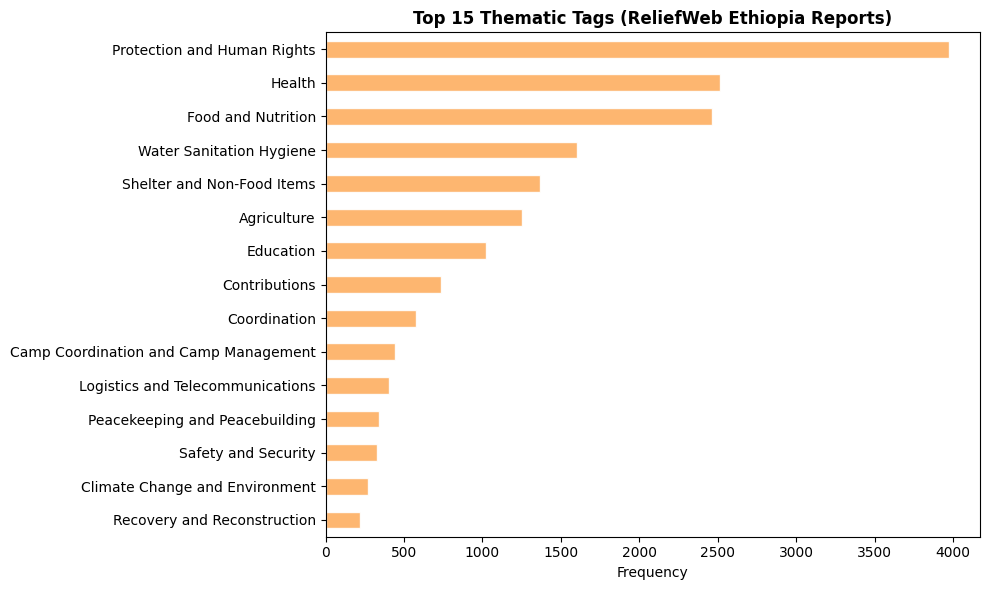

Total unique themes: 20

Top 10 themes:
  Protection and Human Rights: 3974
  Health: 2518
  Food and Nutrition: 2461
  Water Sanitation Hygiene: 1600
  Shelter and Non-Food Items: 1368
  Agriculture: 1255
  Education: 1020
  Contributions: 736
  Coordination: 575
  Camp Coordination and Camp Management: 444


In [14]:
# Extract individual themes (they are semicolon-separated)
all_themes = []
for themes_str in df['themes'].dropna():
    if themes_str:
        all_themes.extend([t.strip() for t in themes_str.split(';') if t.strip()])

theme_series = pd.Series(all_themes)
theme_counts = theme_series.value_counts()

# Plot top themes
top_n = 15
fig, ax = plt.subplots(figsize=(10, 6))
theme_counts.head(top_n).plot(kind='barh', ax=ax, color='#fdae61', edgecolor='white', alpha=0.9)
ax.set_title(f'Top {top_n} Thematic Tags (ReliefWeb Ethiopia Reports)', fontsize=12, fontweight='bold')
ax.set_xlabel('Frequency')
ax.set_ylabel('')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('figures/reliefweb_themes.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Total unique themes: {theme_counts.shape[0]}')
print(f'\nTop 10 themes:')
for theme, count in theme_counts.head(10).items():
    print(f'  {theme}: {count}')

## 14. Save Processed Data

I save the parsed DataFrame as a CSV file in the processed data directory. This file drops the full body text to keep the file size manageable. I save a separate version with body text for any future text analysis.

I also save the monthly counts as a standalone CSV. This file will be loaded directly in Notebook 04 for the cross-source integration analysis.

In [15]:
# Save processed DataFrame (without body text, for easy analysis)
df_meta = df.drop(columns=['body_text']).copy()
df_meta['date'] = df_meta['date'].dt.strftime('%Y-%m-%d')
df_meta['year_month'] = df_meta['year_month'].astype(str)
df_meta.to_csv('data/processed/reliefweb_reports_metadata.csv', index=False, encoding='utf-8')
print(f'Metadata saved: data/processed/reliefweb_reports_metadata.csv ({len(df_meta)} rows)')

# Save full DataFrame with body text
df_full = df.copy()
df_full['date'] = df_full['date'].dt.strftime('%Y-%m-%d')
df_full['year_month'] = df_full['year_month'].astype(str)
df_full.to_csv('data/processed/reliefweb_reports_full.csv', index=False, encoding='utf-8')
print(f'Full data saved: data/processed/reliefweb_reports_full.csv ({len(df_full)} rows)')

# Save monthly counts for Notebook 04
monthly_counts.to_csv('data/processed/reliefweb_monthly_counts.csv', index=False, encoding='utf-8')
print(f'Monthly counts saved: data/processed/reliefweb_monthly_counts.csv ({len(monthly_counts)} rows)')

# Report file sizes
for f_path in ['data/processed/reliefweb_reports_metadata.csv', 
               'data/processed/reliefweb_reports_full.csv',
               'data/processed/reliefweb_monthly_counts.csv']:
    size_kb = os.path.getsize(f_path) / 1024
    print(f'  {f_path}: {size_kb:.0f} KB')

Metadata saved: data/processed/reliefweb_reports_metadata.csv (6295 rows)
Full data saved: data/processed/reliefweb_reports_full.csv (6295 rows)
Monthly counts saved: data/processed/reliefweb_monthly_counts.csv (25 rows)
  data/processed/reliefweb_reports_metadata.csv: 1825 KB
  data/processed/reliefweb_reports_full.csv: 21008 KB
  data/processed/reliefweb_monthly_counts.csv: 1 KB


## 15. Collection Summary

I print a final summary of everything collected and saved in this notebook. This serves as a quick reference and a reproducibility record.

In [16]:
print('=' * 60)
print('RELIEFWEB COLLECTION SUMMARY')
print('=' * 60)
print(f'Source:           ReliefWeb API (api.reliefweb.int)')
print(f'Country:          {COUNTRY}')
print(f'Date range:       {DATE_START} to {DATE_END}')
print(f'Reports collected: {len(df)}')
print(f'Date range found: {df["date"].min()} to {df["date"].max()}')
print(f'Unique sources:   {df["primary_source"].nunique()}')
print(f'Report formats:   {df["format_type"].nunique()}')
print(f'Unique themes:    {theme_counts.shape[0]}')
print()
print('Files saved:')
print('  data/raw/reliefweb_raw.json (complete API responses)')
print('  data/processed/reliefweb_reports_metadata.csv (parsed, no body text)')
print('  data/processed/reliefweb_reports_full.csv (parsed, with body text)')
print('  data/processed/reliefweb_monthly_counts.csv (monthly aggregates)')
print('  figures/reliefweb_monthly_volume.png')
print('  figures/reliefweb_top_sources.png')
print('  figures/reliefweb_format_types.png')
print('  figures/reliefweb_themes.png')
print('=' * 60)

RELIEFWEB COLLECTION SUMMARY
Source:           ReliefWeb API (api.reliefweb.int)
Country:          Ethiopia
Date range:       2020-11-01T00:00:00+00:00 to 2022-11-30T23:59:59+00:00
Reports collected: 6295
Date range found: 2020-11-02 00:00:00+00:00 to 2022-11-30 00:00:00+00:00
Unique sources:   292
Report formats:   11
Unique themes:    20

Files saved:
  data/raw/reliefweb_raw.json (complete API responses)
  data/processed/reliefweb_reports_metadata.csv (parsed, no body text)
  data/processed/reliefweb_reports_full.csv (parsed, with body text)
  data/processed/reliefweb_monthly_counts.csv (monthly aggregates)
  figures/reliefweb_monthly_volume.png
  figures/reliefweb_top_sources.png
  figures/reliefweb_format_types.png
  figures/reliefweb_themes.png
